In [3]:
###### LIBRARY IMPORTS ######
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torchaudio
import json
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import re
from pathlib import Path
from typing import Any, Dict, Iterable, Optional, Union
from SSM_model_V1 import SSMPhonemeModel as SSMPhonemeModelV1
from SSM_model_V2 import SSMPhonemeModel as SSMPhonemeModelV2
from SSM_model_V3 import SSMPhonemeModel as SSMPhonemeModelV3
from SSM_model_V4 import SSMPhonemeModel as SSMPhonemeModelV4
from S2T_CNN_time import S2T_CNN_time_V1
from TIMITDataset import TIMITDataset
import random
from utils import build_phoneme_vocab, collate_fn_ctc, make_json_serializable, save_training_result, collate_fn_ctc_time_domain_padding
from utils import ctc_greedy_decode, edit_distance, compute_batch_per_from_log_probs, decode_batch_to_phonemes, log_message
from functools import partial # for the new collate function
#import torch_xla
#import torch_xla.core.xla_model as xm

seed = 42 # define the seed for pytorch repeatability

In [2]:
###### DEFINE PATHS EITHER FOR GOOGLE COLAB OR LOCALLY ######
import sys
import os

colab = True # decides whether colab or local pc used

if colab:
    from google.colab import drive

    project_root_dir = os.getcwd() # get the root directory of the project
    data_root_dir = os.path.join(project_root_dir, "TIMIT") # define the path to the TIMIT dataset in colab
    drive.mount('/content/drive', force_remount=True) # mount the main drive directory to colab
    sys.path.append('/content/drive/MyDrive/thesis') # to import the SSM_TU directory we need its parent directory
    from SSM_TU.src.model.sequence_layer import SequenceLayer # import the SSM Layer directory

    # unzip the data
    if not os.path.exists("/content/TIMIT"):  # or your dataset folder
        !unzip -q /content/drive/MyDrive/thesis/TIMIT.zip -d /content/TIMIT
    else:
        print("TIMIT folder already exists in /content/TIMIT folder")

    base_results_dir = r"/content/drive/MyDrive/thesis/results"

    # check the content of the main directory
    print("TIMIT dataset contents")
    !ls /content/TIMIT
else:
    project_root_dir = os.getcwd() # get the root directory of the project
    data_root_dir = project_root_dir
    base_results_dir = os.path.join(project_root_dir, "results")

vocabulary_dir = os.path.join(project_root_dir, "vocabulary")
phoneme_to_idx_vocab_filename = "phoneme_to_idx.json"
idx_to_phoneme_vocab_filename = "idx_to_phoneme.json"
train_data_csv = os.path.join(data_root_dir, "train_data.csv")
test_data_csv = os.path.join(data_root_dir, "test_data.csv")

print(f"Project root directory: {project_root_dir}")
print(f"Data root directory: {data_root_dir}")
print(f"Vocabulary directory: {vocabulary_dir}")
print(f"train_data.csv: {train_data_csv}")
print(f"test_data.csv: {test_data_csv}")




Mounted at /content/drive
TIMIT dataset contents
data	      README.DOC    test_data.csv  TIMITDIC.TXT
PHONCODE.DOC  SPKRINFO.TXT  TESTSET.DOC    train_data.csv
PROMPTS.TXT   SPKRSENT.TXT  TIMITDIC.DOC
Project root directory: /content
Data root directory: /content/TIMIT
Vocabulary directory: /content/vocabulary
train_data.csv: /content/TIMIT/train_data.csv
test_data.csv: /content/TIMIT/test_data.csv


In [4]:
####### DEVICE SPECIFICATIONS ######

# GPU info (only works if CUDA runtime is active)
!nvidia-smi

complex_use = False  # MPS cannot handle complex tensors

print("PyTorch version:", torch.__version__)

# --- GPU / MPS checks ---
mps_available = torch.backends.mps.is_available()
cuda_available = torch.cuda.is_available()

print("MPS available:", mps_available)
print("MPS built:", torch.backends.mps.is_built())
print("CUDA available:", cuda_available)
print("CUDA built:", torch.backends.cuda.is_built())

# --- TPU check ---
tpu_available = False

#try:
#    tpu_available = True
#    tpu_device = xm.xla_device()
#    print("TPU detected:", tpu_device)

#except ImportError:
#    print("torch_xla not available → TPU not available")


# --- DEVICE SELECTION ---
if cuda_available:
    device = torch.device("cuda")
    print("🚀 Using GPU (CUDA)")
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    print("Setting seed for cuda")

    torch.backends.cudnn.deterministic = True
    print("Cuda is deterministic")
    torch.backends.cudnn.benchmark = False
    print("Cuda benchmark = Fakse -> uses fixed algorithm") 
#elif tpu_available:
#    device = tpu_device
#    print("🚀 Using TPU")
elif mps_available and not complex_use:
    device = torch.device("mps")
    print("🚀 Using GPU (MPS)")

else:
    device = torch.device("cpu")
    print("⚠️ Using CPU")

print("Final device:", device)

Mon Jun 22 16:47:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
###### CHECK THE OUTPUT OF THE torchaudio.load() method #####
test_waveform, test_sample_rate = torchaudio.load("/Users/atis/Desktop/MasterArbeit/Code/data/TEST/DR2/FDRD1/SA1.WAV")
features = mel_transform(test_waveform)
print("waveform 1 output:")
print("----------------")
print("Type of Waveform: ", type(test_waveform))
print("Shape of Waveform: ", test_waveform.shape)
print("Waveform:", test_waveform)

print("sample_rate 1 output:")
print("-------------------")
print("sample rate type:", type(test_sample_rate))
print("Sample rate:", test_sample_rate)

print("features 1 output:")
print("-------------------")
print("features type:", type(features))
print("features shape:", features.shape)

test_waveform, test_sample_rate = torchaudio.load("/Users/atis/Desktop/MasterArbeit/Code/data/TEST/DR2/FDRD1/SA2.WAV")
features = mel_transform(test_waveform)
print("waveform 2 output:")
print("----------------")
print("Type of Waveform: ", type(test_waveform))
print("Shape of Waveform: ", test_waveform.shape)
print("Waveform:", test_waveform)

print("sample_rate 2 output:")
print("-------------------")
print("sample rate type:", type(test_sample_rate))
print("Sample rate:", test_sample_rate)

print("features 2 output:")
print("-------------------")
print("features type:", type(features))
print("features shape:", features.shape)

waveform 1 output:
----------------
Type of Waveform:  <class 'torch.Tensor'>
Shape of Waveform:  torch.Size([1, 55911])
Waveform: tensor([[ 9.1553e-05,  6.1035e-05,  0.0000e+00,  ..., -6.1035e-05,
          6.1035e-05, -1.2207e-04]])
sample_rate 1 output:
-------------------
sample rate type: <class 'int'>
Sample rate: 16000
features 1 output:
-------------------
features type: <class 'torch.Tensor'>
features shape: torch.Size([1, 80, 350])
waveform 2 output:
----------------
Type of Waveform:  <class 'torch.Tensor'>
Shape of Waveform:  torch.Size([1, 47104])
Waveform: tensor([[ 1.5259e-04,  3.0518e-05, -3.0518e-05,  ..., -1.2207e-04,
          6.1035e-05, -6.1035e-05]])
sample_rate 2 output:
-------------------
sample rate type: <class 'int'>
Sample rate: 16000
features 2 output:
-------------------
features type: <class 'torch.Tensor'>
features shape: torch.Size([1, 80, 295])


In [5]:
####### BUILDING the VOCABULARY #######
if (os.path.exists(os.path.join(vocabulary_dir, phoneme_to_idx_vocab_filename)) == False or 
    os.path.exists(os.path.join(vocabulary_dir, idx_to_phoneme_vocab_filename)) == False):
    phoneme_to_idx_vocab, idx_to_phoneme_vocab = build_phoneme_vocab(root_dir=data_root_dir,
                                                                     save_dir=vocabulary_dir)
    print(f"The following vocabulary files were created:\n{phoneme_to_idx_vocab_filename}\n{idx_to_phoneme_vocab_filename}")
else:
    with open(os.path.join(vocabulary_dir, phoneme_to_idx_vocab_filename), "r") as file:
        phoneme_to_idx_vocab = json.load(file)
    with open(os.path.join(vocabulary_dir, idx_to_phoneme_vocab_filename), "r") as file:
        idx_to_phoneme_vocab = json.load(file)
        
        # convert keys back to int
        idx_to_phoneme_vocab = {int(k): v for k, v in idx_to_phoneme_vocab.items()}
    print(f"the vocabulary files already exist in the vocabulary directory:\n{phoneme_to_idx_vocab_filename}\n{idx_to_phoneme_vocab_filename}")

The following vocabulary files were created:
phoneme_to_idx.json
idx_to_phoneme.json


In [15]:
####### Training relevant objects ######
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

# The Mel spectrogram does the following:
#1. Split signal into windows
#2. Apply Fourier Transform (FFT)
#3. Convert frequencies to Mel scale
#4. Output energy per Mel band
mel_transform_n_mels = 256 # number of features in each timing window after transformation
mel_transform_nfft = 600
mel_transform_hop_length = 160
mel_transform_win_length = 600
mel_transform_sample_rate = 16000
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=mel_transform_sample_rate,
    n_fft=mel_transform_nfft, # FFT window size => how many samples are used for frequency analysis
    hop_length=mel_transform_hop_length, # step size between windows => at 16kHz a hop length of 160 means a stepsize of 10ms
    win_length=mel_transform_win_length, # Actual window size applied before FFT => at 16kHz a window size of 400 means 25ms window length
    n_mels=mel_transform_n_mels # Number of frequency bins after Mel conversion => number of frequency elements in each window AFTER conversion
)
batch_size = 8

# defining the model
ssm_vocab_size = len(phoneme_to_idx_vocab)
ssm_dropout = 0.0
ssm_num_layers = 4
ssm_model_version = "V4"

# Default values for parameters that only exist in some model versions
num_of_linear_layers = None
linear_in_features = None
linear_out_features = None
linear_dropout = None
last_linear_output = None


model_dict = {
    "model_type": "",
    "model_version": "",
}
#device = torch.device("cpu")
if ssm_model_version == "V1":
    ssm_d_in_d_out = mel_transform_n_mels
    d_in = ssm_d_in_d_out
    d_state = [256, 256, 256, 256]
    d_out = ssm_d_in_d_out
    
    ssm_model = SSMPhonemeModelV1(d_in=ssm_d_in_d_out,
                                  vocab_size=ssm_vocab_size,
                                  d_state=d_state,
                                  d_out=ssm_d_in_d_out,
                                  dropout=ssm_dropout).to(device=device)
    model_dict["model_type"] = "SSM"
    model_dict["model_version"] = ssm_model_version
    model_dict.update({
        "ssm_d_in": d_in,
        "ssm_d_state": d_state,
        "ssm_d_out": d_out,
    })
    
elif ssm_model_version == "V2":
    ssm_d_in_d_out = mel_transform_n_mels
    d_in = ssm_d_in_d_out
    d_state = 256
    d_out = ssm_d_in_d_out

    ssm_model = SSMPhonemeModelV2(d_in=d_in,
                                  vocab_size=ssm_vocab_size,
                                  d_state=d_state,
                                  dropout=ssm_dropout,
                                  num_layers=ssm_num_layers).to(device=device)
    model_dict["model_type"] = "SSM"
    model_dict["model_version"] = ssm_model_version
    model_dict.update({
        "ssm_d_in": d_in,
        "ssm_d_state": d_state,
        "ssm_d_out": d_out,
        "ssm_num_layers": ssm_num_layers
    })
    
elif ssm_model_version == "V3": # linear layer version
    ssm_d_in_d_out = [mel_transform_n_mels, 128, 192, 256]
    d_in = ssm_d_in_d_out
    d_state = [256, 256, 256, 256]
    d_out = ssm_d_in_d_out
    
    num_of_linear_layers = ssm_num_layers
    linear_in_features = ssm_d_in_d_out
    last_linear_output = 120
    linear_out_features = linear_in_features[1:] + [last_linear_output]
    linear_dropout = 0.1

    ssm_model = SSMPhonemeModelV3(d_state=d_state,
                                  d_in=d_in,
                                  d_out=d_out,
                                  num_of_ssm_layers=ssm_num_layers,
                                  linear_in_features=linear_in_features,
                                  linear_out_features=linear_out_features,
                                  num_of_linear_layers=num_of_linear_layers,
                                  vocab_size=ssm_vocab_size,
                                  ssm_dropout=ssm_dropout,
                                  linear_dropout=linear_dropout).to(device=device)
    
    model_dict["model_type"] = "SSM"
    model_dict["model_version"] = ssm_model_version
    model_dict.update({
        "ssm_d_in": d_in,
        "ssm_d_state": d_state,
        "ssm_d_out": d_out,
        "num_of_ssm_layers": ssm_num_layers,
        "num_of_linear_layers": num_of_linear_layers,
        "linear_in_features": ssm_num_layers,
        "last_linear_output": last_linear_output,
        "linear_out_features": linear_out_features,
        "linear_dropout": linear_dropout,
    })
    
elif ssm_model_version == "V4":
    d_in = [mel_transform_n_mels, 312, 368, 400]
    d_state = [128, 128, 128, 128]
    d_out = [312, 368, 400, 400]
    
    linear_dropout = 0.4

    norm = True
    norm_type = "bn"
    act = "LeakyRELu"
    trainable_SkipLayer=True

    ssm_model = SSMPhonemeModelV4(d_state=d_state,
                                  d_in=d_in,
                                  d_out=d_out,
                                  num_of_ssm_layers=ssm_num_layers,
                                  vocab_size=ssm_vocab_size,
                                  ssm_dropout=ssm_dropout,
                                  linear_dropout=linear_dropout,
                                  norm=norm,
                                  norm_type=norm_type,
                                  act=act,
                                  trainable_SkipLayer=trainable_SkipLayer).to(device=device)
    model_dict["model_type"] = "SSM"
    model_dict["model_version"] = ssm_model_version
    model_dict.update({
        "ssm_d_in": d_in,
        "ssm_d_state": d_state,
        "ssm_d_out": d_out,
        "num_of_ssm_layers": ssm_num_layers,
        "linear_dropout": linear_dropout,
        "norm": norm,
        "norm_type": norm_type,
        "act": act,
        "trainable_SkipLayer": trainable_SkipLayer

    })

elif ssm_model_version == "CNN_time_domain_V1":
    in_channels = [1, 32, 64, 128]
    out_channels = [32, 64, 128, 256]
    lin_dropout = 0.3
    kernel_size=5
    padding=2,
    padding_type="non-causal"
    stride=1

    ssm_model = S2T_CNN_time_V1(vocab_size=ssm_vocab_size,
                                kernel_size=kernel_size,
                                padding=padding,
                                padding_type=padding_type,
                                stride=stride,
                                in_channels=in_channels,
                                out_channels=out_channels,
                                lin_dropout=lin_dropout
                                ).to(device=device)
    
    model_dict["model_type"] = "CNN"
    model_dict["model_version"] = ssm_model_version
    model_dict.update({
        "in_channels": in_channels,
        "out_channels": out_channels,
        "linear_dropout": lin_dropout,
        "kernel_size": kernel_size,
        "padding": padding,
        "padding_type": padding_type,
        "stride": stride,
    })
    

# CTC loss function
ctc_zero_infinity = True
loss_fn = nn.CTCLoss(blank=0,
                     zero_infinity=ctc_zero_infinity) # to nullyify the infinity effects of possible very short sequences

# optimizer
optimizer_type = "AdamW"
optimizer_dict = {}
if optimizer_type == "Adam":
    opt_Adam_lr = 0.001
    opt_Adam_weight_decay = 1e-4
    optimizer = torch.optim.Adam(
        params=ssm_model.parameters(),
        lr = opt_Adam_lr,
        weight_decay=opt_Adam_weight_decay)
    
    
    optimizer_dict = {
        "type": optimizer_type,
        "learning_rate": opt_Adam_lr,
        "weight_decay": opt_Adam_weight_decay,
    }

elif optimizer_type == "AdamW":
    opt_AdamW_other_layer_weight_decay = 0.01
    opt_AdamW_ssm_layer_weight_decay = 0
    
    opt_AdamW_lr = 5e-4
    opt_AdamW_ssm_lr_factor = 1
    opt_AdamW_other_lr_factor = 4

    params_ssm_lr = [param for name, param in ssm_model.named_parameters() if 'B' in name or 'C' in name or 'Lambda' in name or 'log_step' in name] # parameters of the sequence layers
    params_other_lr = [param for name, param in ssm_model.named_parameters() if 'B' not in name and 'C' not in name and 'Lambda' not in name and 'log_step' not in name] # parameters of other layers like the Linear Decoder

    optimizer_dict = {
        "type": optimizer_type,
        "learning_rate": opt_AdamW_lr,
        "ssm_lr_factor": opt_AdamW_ssm_lr_factor,
        "other_lr_factor": opt_AdamW_other_lr_factor,
        "ssm_weight_decay": opt_AdamW_ssm_layer_weight_decay,
        "other_weight_decay": opt_AdamW_other_layer_weight_decay,
    }


    optimizer = torch.optim.AdamW([
            {'params': params_ssm_lr, 'lr':opt_AdamW_ssm_lr_factor * opt_AdamW_lr, 'weight_decay': opt_AdamW_ssm_layer_weight_decay},
            {'params': params_other_lr, 'lr': opt_AdamW_other_lr_factor * opt_AdamW_lr, 'weight_decay': opt_AdamW_other_layer_weight_decay},
        ], 
    lr=opt_AdamW_lr, weight_decay=opt_AdamW_other_layer_weight_decay) # default values for lr and weight decay

print(f"✅ {ssm_model_version} model is used")

# Scheduler
scheduler_type = "ReduceLROnPlateau"

StepLR_scheduler_step_size = 25
StepLR_scheduler_gamma = 0.5

plateau_scheduler_mode = "min"
plateau_scheduler_factor = 0.3
plateau_scheduler_patience = 3
plateau_scheduler_threshold = 1e-3
plateau_scheduler_minlr = 1e-5

if scheduler_type == "StepLR":
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer=optimizer,
                                                step_size=StepLR_scheduler_step_size,
                                                gamma=StepLR_scheduler_gamma)
    print("✅ StepLR scheduler is used")

elif scheduler_type == "ReduceLROnPlateau":
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode=plateau_scheduler_mode,
        factor=plateau_scheduler_factor,
        patience=plateau_scheduler_patience,
        threshold=plateau_scheduler_threshold,
        min_lr=plateau_scheduler_minlr
    )
    print("✅ ReduceLROnPlateu scheduler is used")

# Gradient clipping
use_gradient_clipping = True


✅ V4 model is used
✅ ReduceLROnPlateu scheduler is used


In [16]:
####### DATASETS and DATALOADERS #######

padding_after_mel_transform = False
collate_function = ""
if padding_after_mel_transform:
    dataloader_collate_fn = collate_fn_ctc
    collate_function = "collate_fn_ctc"
else:
    # creating the partial function to be able to set the collate_fn with more parameters in the dataloader
    dataloader_collate_fn = partial(
        collate_fn_ctc_time_domain_padding,
        mel_transform=mel_transform,
        hop_length=mel_transform_hop_length
    )
    collate_function = "collate_fn_ctc_time_domain_padding"

train_dataset = TIMITDataset(
    csv_file=train_data_csv,
    train_or_test="TRAIN",
    root_dir=project_root_dir,
    phoneme_to_idx_vocab=phoneme_to_idx_vocab,
    transform=mel_transform,
)

val_dataset = TIMITDataset(
    csv_file=test_data_csv,
    train_or_test="TEST",
    root_dir=project_root_dir,
    phoneme_to_idx_vocab=phoneme_to_idx_vocab,
    transform=mel_transform,
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=dataloader_collate_fn

)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=dataloader_collate_fn
)

TRAIN Dataset creation process...
Filtering dataframe to only include TRAIN samples
Checked -> whole dataset belongs to TRAIN
Creating cache directory
Creating the samples dictionary...
Load the waveforms...
Pad the time domain tensors...
100/4620 waveforms padded
200/4620 waveforms padded
300/4620 waveforms padded
400/4620 waveforms padded
500/4620 waveforms padded
600/4620 waveforms padded
700/4620 waveforms padded
800/4620 waveforms padded
900/4620 waveforms padded
1000/4620 waveforms padded
1100/4620 waveforms padded
1200/4620 waveforms padded
1300/4620 waveforms padded
1400/4620 waveforms padded
1500/4620 waveforms padded
1600/4620 waveforms padded
1700/4620 waveforms padded
1800/4620 waveforms padded
1900/4620 waveforms padded
2000/4620 waveforms padded
2100/4620 waveforms padded
2200/4620 waveforms padded
2300/4620 waveforms padded
2400/4620 waveforms padded
2500/4620 waveforms padded
2600/4620 waveforms padded
2700/4620 waveforms padded
2800/4620 waveforms padded
2900/4620 wave

In [9]:
####### TESTING THE SHAPES OF ONE BATCH ######
batch = next(iter(train_dataloader))
features, feature_lengths, labels, label_lengths = batch

print("features shape:",features.shape)
print("features_length:",feature_lengths.shape)
print("labels shape:",labels.shape)
print("labels length:",label_lengths.shape)
print("length of training dataset:",len(train_dataset))
print("length of validation dataset:", len(val_dataset))

features shape: torch.Size([8, 779, 80])
features_length: torch.Size([8])
labels shape: torch.Size([271])
labels length: torch.Size([8])
length of training dataset: 4620
length of validation dataset: 1680


In [17]:
######## CHECKPOINT handling and function for checking nan/infinity values in case of exploding gradients #######
def load_model_from_checkpoint(use_scheduler: bool) -> tuple:
    """Loads the model from the last saved checkpoint
    
    Parameters
    ----------
    use_scheduler: bool
        To decide whether scheduler was used or not

    Returns
    -------
    tuple: 
        0. element: start_epoch
        1. element train_epoch_losses
        2. element val_epoch_losses
    """
    checkpoint = torch.load("checkpoint.pt", map_location=device)

    ssm_model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if use_scheduler:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    start_epoch = checkpoint["epoch"] + 1

    train_epoch_losses = checkpoint.get("train_epoch_losses",[])
    val_epoch_losses = checkpoint.get("val_epoch_losses",[])
    train_epoch_PERs = checkpoint.get("train_epoch_PERs", [])
    val_epoch_PERs = checkpoint.get("val_epoch_PERs", [])

    return start_epoch, train_epoch_losses, val_epoch_losses, train_epoch_PERs, val_epoch_PERs

def create_checkpoint(epoch: int,
                      use_scheduler: bool,
                      train_epoch_losses: list,
                      val_epoch_losses: list,
                      train_epoch_PERs: list,
                      val_epoch_PERs: list) -> None:
    """Creates a Checkpoint to save the current status and informations about the trained model
    
    Parameters
    ----------
    epoch: int
        The current epoch
    
    use_scheduler: bool
        To decide whether scheduler was used or not
    
    train_epoch_losses: list
        The list of the training epoch losses until this point
    
    val_epoch_losses: list
        The list of the validation epoch losses until this point

    Returns
    -------
    None
    """
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": ssm_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if use_scheduler else None,
        "train_epoch_losses": train_epoch_losses,
        "val_epoch_losses": val_epoch_losses,
        "train_epoch_PERs": train_epoch_PERs,
        "val_epoch_PERs": val_epoch_PERs,

    }

    torch.save(checkpoint, f"checkpoint.pt")

def check_finite_tensor(tensor, name: str):
    if not torch.isfinite(tensor).all():
        raise RuntimeError(
            f"Non-finite values detected in {name}. "
            f"min={tensor.nan_to_num().min().item():.4f}, "
            f"max={tensor.nan_to_num().max().item():.4f}"
        )

In [18]:
###### Training and Validation loop with optional PER ######

training_start_time = time.time()

epochs = 60
use_scheduler = True
compute_per = True   # set to False to skip PER computation and PER logging for saving time
resume_from_checkpoint = False

print("device: ", device)
print("batch_size: ",batch_size)
print("ssm model version:", ssm_model_version)
print("number of ssm layers:", ssm_num_layers)
print("Scheduler: ", scheduler_type)
print("Use Checkpoint: ", resume_from_checkpoint)

blank_idx = 0   # CTC blank index

if resume_from_checkpoint:
    (start_epoch,
     train_epoch_losses,
     val_epoch_losses,
     train_epoch_PERs,
     val_epoch_PERs
    ) = load_model_from_checkpoint(use_scheduler=use_scheduler)
    
    file_mode = "a"
else:
    start_epoch = 0
    train_epoch_losses = []
    val_epoch_losses = []
    train_epoch_PERs = []
    val_epoch_PERs = []

    file_mode="w"

log_file_loss_and_PER_path = "training_log_loss_and_PER.txt"
log_file_predictions_path = "training_log_predictions.txt"
log_file_loss_and_PER = open(log_file_loss_and_PER_path, file_mode)
log_file_predictions = open(log_file_predictions_path, file_mode)

for epoch in range(start_epoch, epochs):
    true_train_batch_loss = 0.0
    epoch_train_loss = 0.0

    true_val_batch_loss = 0.0
    epoch_val_loss = 0.0

    total_train_edit_distance = 0
    total_train_target_length = 0
    epoch_train_per = None

    total_val_edit_distance = 0
    total_val_target_length = 0
    epoch_val_per = None

    ##### TRAINING #####
    ssm_model.train()

    for batch, (X_train, X_train_length, y_train, y_train_length) in enumerate(train_dataloader):
        # send tensors to device
        X_train = X_train.to(device)
        y_train = y_train.to(device)

        # forward pass
        logits = ssm_model(X_train)                    # [B, T, C]
        log_probs = logits.log_softmax(dim=-1)        # [B, T, C]
        log_probs_ctc = log_probs.transpose(0, 1)     # [T, B, C]

        #checking exploding gradients for the log probabilities
        check_finite_tensor(log_probs, "log_probs")
        
        # loss
        loss = loss_fn(log_probs_ctc, y_train, X_train_length, y_train_length)

        # checking exploding gradients for the loss
        check_finite_tensor(loss, "loss")

        # accumulate weighted epoch loss
        true_train_batch_loss += loss.item() * len(X_train)

        # compute PER for this batch only if enabled
        if compute_per and (epoch == 0 or (epoch + 1) % 10 == 0):
            batch_train_per, batch_train_edits, batch_train_targets = compute_batch_per_from_log_probs(
                log_probs=log_probs,
                input_lengths=X_train_length,
                targets=y_train,
                target_lengths=y_train_length,
                blank_idx=blank_idx
            )

            total_train_edit_distance += batch_train_edits
            total_train_target_length += batch_train_targets

        # backward
        optimizer.zero_grad()
        loss.backward()

        if use_gradient_clipping:
            torch.nn.utils.clip_grad_norm_(
            ssm_model.parameters(),
            max_norm=1.0
)

        optimizer.step()

        if batch % 30 == 0: # calculate PER value in the first and last epoch
            if compute_per and (epoch == 0 or (epoch + 1) % 10 ==0):
                log_message(
                    f"Training batch: {batch + 1}/{len(train_dataloader)} | "
                    f"Batch loss: {loss.item():.4f} | "
                    f"Batch PER: {batch_train_per * 100:.2f}%",
                    log_file_loss_and_PER
                )
            else:
                log_message(
                    f"Training batch: {batch + 1}/{len(train_dataloader)} | "
                    f"Batch loss: {loss.item():.4f}",
                    log_file_loss_and_PER
                )

    epoch_train_loss = true_train_batch_loss / len(train_dataset)

    if compute_per and (epoch == 0 or (epoch + 1) % 10 == 0):
        epoch_train_per = (
            total_train_edit_distance / total_train_target_length
            if total_train_target_length > 0 else 0.0
        )
        train_epoch_PERs.append(epoch_train_per)
    else:
        train_epoch_PERs.append(None)

    train_epoch_losses.append(epoch_train_loss)

    ##### VALIDATION #####
    ssm_model.eval()

    with torch.inference_mode():
        for batch, (X_val, X_val_length, y_val, y_val_length) in enumerate(val_dataloader):
            # send tensors to device
            X_val = X_val.to(device)
            y_val = y_val.to(device)

            # forward pass
            logits = ssm_model(X_val)                  # [B, T, C]
            log_probs = logits.log_softmax(dim=-1)    # [B, T, C]
            log_probs_ctc = log_probs.transpose(0, 1) # [T, B, C]

            # loss
            loss = loss_fn(log_probs_ctc, y_val, X_val_length, y_val_length)

            # accumulate weighted epoch loss
            true_val_batch_loss += loss.item() * len(X_val)

            # compute PER for this batch only if enabled
            if compute_per and (epoch == 0 or (epoch + 1) % 10 == 0):
                batch_val_per, batch_val_edits, batch_val_targets = compute_batch_per_from_log_probs(
                    log_probs=log_probs,
                    input_lengths=X_val_length,
                    targets=y_val,
                    target_lengths=y_val_length,
                    blank_idx=blank_idx
                )

                total_val_edit_distance += batch_val_edits
                total_val_target_length += batch_val_targets

            if batch % 15 == 0: # calculate PER value in the first and last epoch
                if compute_per and (epoch == 0 or (epoch + 1) % 10 == 0):
                    log_message(
                        f"Validation batch: {batch + 1}/{len(val_dataloader)} | "
                        f"Batch loss: {loss.item():.4f} | "
                        f"Batch PER: {batch_val_per * 100:.2f}%",
                        log_file_loss_and_PER
                    )
                else:
                    log_message(
                        f"Validation batch: {batch + 1}/{len(val_dataloader)} | "
                        f"Batch loss: {loss.item():.4f}",
                        log_file_loss_and_PER
                    )

    epoch_val_loss = true_val_batch_loss / len(val_dataset)

    if compute_per and (epoch == 0 or (epoch + 1) % 10 ==0):
        epoch_val_per = (
            total_val_edit_distance / total_val_target_length
            if total_val_target_length > 0 else 0.0
        )
        val_epoch_PERs.append(epoch_val_per)
    else:
        val_epoch_PERs.append(None)

    val_epoch_losses.append(epoch_val_loss)

    # use scheduler LRStepScheduler if use_scheduler is True
    if use_scheduler:
        if scheduler_type == "StepLR":
            scheduler.step()
        elif scheduler_type == "ReduceLROnPlateau":
            scheduler.step(epoch_val_loss)
        print("LR:", optimizer.param_groups[0]["lr"])

    # Create checkpoint after every epoch so be able to restart if something went wrong
    create_checkpoint(epoch=epoch,
                      use_scheduler=use_scheduler,
                      train_epoch_losses=train_epoch_losses,
                      val_epoch_losses=val_epoch_losses,
                      train_epoch_PERs=train_epoch_PERs,
                      val_epoch_PERs=val_epoch_PERs)

    log_message("-------------------------------------------------------------------------------------------------------", log_file_loss_and_PER)

    if compute_per and (epoch == 0 or (epoch + 1) % 10 == 0):
        log_message(
            f"Epoch: {epoch + 1} | Training loss: {epoch_train_loss:.6f} | Training PER: {epoch_train_per * 100:.2f}%",
            log_file_loss_and_PER
        )
        log_message(
            f"Epoch: {epoch + 1} | Validation loss: {epoch_val_loss:.6f} | Validation PER: {epoch_val_per * 100:.2f}%",
            log_file_loss_and_PER
        )
    else:
        log_message(
            f"Epoch: {epoch + 1} | Training loss: {epoch_train_loss:.6f}",
            log_file_loss_and_PER
        )
        log_message(
            f"Epoch: {epoch + 1} | Validation loss: {epoch_val_loss:.6f}",
            log_file_loss_and_PER
        )

    log_message("-------------------------------------------------------------------------------------------------------", log_file_loss_and_PER)

    ##### QUALITATIVE VALIDATION PREDICTIONS EVERY 10 EPOCHS #####
    if (epoch + 1) % 10 == 0:
        log_message(f"########## QUALITATIVE VALIDATION CHECK AFTER EPOCH {epoch + 1} ##########", log_file_predictions)

        ssm_model.eval()
        with torch.inference_mode():
            # take one batch from validation loader
            X_obs, X_obs_length, y_obs, y_obs_length = next(iter(val_dataloader))

            X_obs = X_obs.to(device)
            y_obs = y_obs.to(device)

            logits_obs = ssm_model(X_obs)
            log_probs_obs = logits_obs.log_softmax(dim=-1)

            decoded_examples = decode_batch_to_phonemes(
                log_probs=log_probs_obs,
                input_lengths=X_obs_length,
                targets=y_obs,
                target_lengths=y_obs_length,
                idx_to_phoneme=idx_to_phoneme_vocab,
                blank_idx=blank_idx
            )

            # show only a few examples
            for i in range(min(5, len(decoded_examples))):
                pred_phonemes, tgt_phonemes = decoded_examples[i]

                log_message(f"Example {i + 1}", log_file_predictions)
                log_message(f"PRED: {' '.join(pred_phonemes)}", log_file_predictions)
                log_message(f"TGT : {' '.join(tgt_phonemes)}", log_file_predictions)
                log_message("--------------------------------------------------", log_file_predictions)

training_end_time = time.time()
elapsed_time = (training_end_time - training_start_time) / 60
log_message(f"Total training and validation time is: {elapsed_time:.2f} minutes", log_file_loss_and_PER)
log_message(f"Total training and validation time is: {elapsed_time:.2f} minutes", log_file_predictions)

# close the file handlers of the log files
log_file_loss_and_PER.close()
log_file_predictions.close()

device:  cuda
batch_size:  8
ssm model version: V4
number of ssm layers: 4
Scheduler:  ReduceLROnPlateau
Use Checkpoint:  False
Training batch: 1/578 | Batch loss: 29.1462 | Batch PER: 694.38%
Training batch: 31/578 | Batch loss: 4.5824 | Batch PER: 93.24%
Training batch: 61/578 | Batch loss: 4.2809 | Batch PER: 97.67%
Training batch: 91/578 | Batch loss: 3.8942 | Batch PER: 99.68%
Training batch: 121/578 | Batch loss: 3.9791 | Batch PER: 96.23%
Training batch: 151/578 | Batch loss: 4.2817 | Batch PER: 97.55%
Training batch: 181/578 | Batch loss: 4.5606 | Batch PER: 96.44%
Training batch: 211/578 | Batch loss: 3.4851 | Batch PER: 98.20%
Training batch: 241/578 | Batch loss: 3.8915 | Batch PER: 98.63%
Training batch: 271/578 | Batch loss: 3.5148 | Batch PER: 100.00%
Training batch: 301/578 | Batch loss: 3.7147 | Batch PER: 92.00%
Training batch: 331/578 | Batch loss: 3.4796 | Batch PER: 94.10%
Training batch: 361/578 | Batch loss: 4.0344 | Batch PER: 88.21%
Training batch: 391/578 | Bat

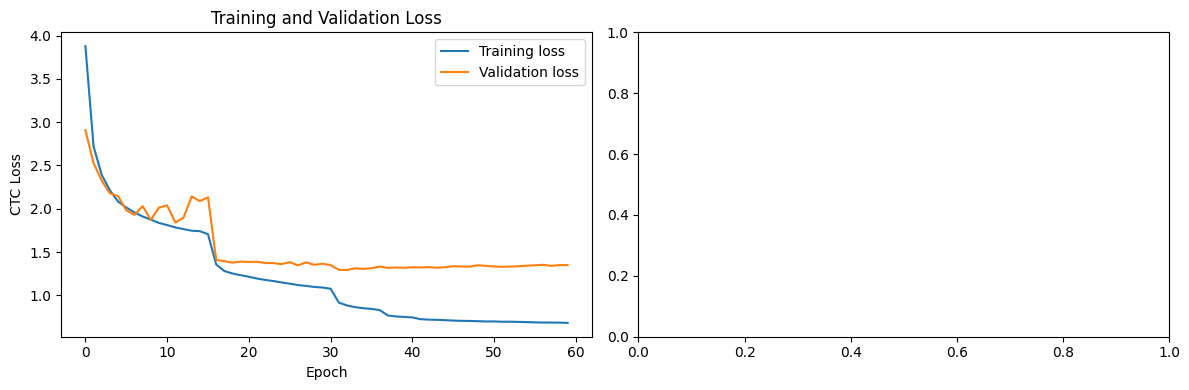

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(train_epoch_losses, label="Training loss")
axes[0].plot(val_epoch_losses, label="Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CTC Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()

# PER plot
if compute_per == False:
    train_epoch_PERs_percent = [per * 100 for per in train_epoch_PERs]
    val_epoch_PERs_percent = [per * 100 for per in val_epoch_PERs]
    axes[1].plot(train_epoch_PERs_percent, label="Training PER")
    axes[1].plot(val_epoch_PERs_percent, label="Validation PER")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("PER (%)")
    axes[1].set_title("Training and Validation PER")
    axes[1].legend()

fig.tight_layout()
plt.show()

In [20]:
min_train_epoch_loss = min(train_epoch_losses)
min_val_epoch_loss = min(val_epoch_losses)

experiment_config = {
    # training loop
    "epochs": epochs,
    "use_scheduler": use_scheduler,
    "training_start_time": training_start_time,
    "training_end_time": training_end_time,
    "elapsed_time_minutes": elapsed_time,
    "min_train_epoch_loss": min_train_epoch_loss,
    "min_val_epoch_loss": min_val_epoch_loss,
    

    "batch_size": batch_size,
    "seed": seed,

    # Dataset settings
    "padding_after_mel_transform": padding_after_mel_transform,
    "collate_function": collate_function,

    # mel spectrogram settings
    "mel_transform_n_mels": mel_transform_n_mels,
    "mel_transform_nfft": mel_transform_nfft,
    "mel_transform_hop_length": mel_transform_hop_length,
    "mel_transform_win_length": mel_transform_win_length,
    "mel_transform_sample_rate": mel_transform_sample_rate,

    # model settings
    "model_info": model_dict,
    
    # model settings - V3 only
    "num_of_linear_layers": num_of_linear_layers,
    "linear_in_features": linear_in_features,
    "linear_out_features": linear_out_features,
    "linear_dropout": linear_dropout,
    "last_linear_output": last_linear_output,
    
    # loss settings
    "ctc_zero_infinity": ctc_zero_infinity,
    "blank_index": 0,

    # optimizer settings
    "optimizer": optimizer_dict,

    # scheduler settings
    "scheduler_name": scheduler_type,
    "StepLR_scheduler_step_size": StepLR_scheduler_step_size,
    "StepLR_scheduler_gamma": StepLR_scheduler_gamma,
    "Plateau_scheduler_mode": plateau_scheduler_mode,
    "Plateau_scheduler_factor": plateau_scheduler_factor,
    "Plateau_scheduler_patience": plateau_scheduler_patience,
    "Plateau_scheduler_threshold": plateau_scheduler_threshold,
    "Plateau_scheduler_minlr": plateau_scheduler_minlr,

    # gradient_clipping
    "use_gradient_clipping": use_gradient_clipping,

    # vocabulary
    "phoneme_to_idx_vocab": phoneme_to_idx_vocab,
}

losses_and_accuracies_config = {
    "train_epoch_losses": train_epoch_losses,
    "train_epoch_accuracies": train_epoch_PERs,
    "val_epoch_losses": val_epoch_losses,
    "val_epoch_accuracies": val_epoch_PERs,
}

In [21]:
###### SAVE THE RESULTS #####
result_dir = save_training_result(
    figures=fig,
    model=ssm_model,
    config=experiment_config,
    base_results_dir=base_results_dir,
    log_files=[
        log_file_loss_and_PER_path,
        log_file_predictions_path
    ]
)

losses_and_accuracies_path = Path(result_dir) / "losses_and_accuracies.json"
with open(losses_and_accuracies_path, "w") as f:
    json.dump(losses_and_accuracies_config, f, indent=4)

print(f"✅ Saved training results to: {result_dir}")

✅ Saved training results to: /content/drive/MyDrive/thesis/results/result_6
